KNN classifier assume that similar data points share same labels but in high dimensional space this assumption does not hold true.

Assume all sample data is uniformly distributed within unit cube [0,1] and will investigate how much space k nearest neighbors (assuming k = 10) of a test point inside the cube will take.

Let ℓ be the edge length of the smallest hyper-cube that contains all k-nearest neighbor of a test point. 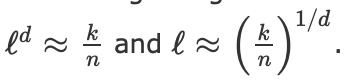.

If n=1000, how big is ℓ? How much edge length require for sample = 1000. Almost entire space is require to find 10 nearest neighbors.



In [ ]:
n_neighbors = 10
dimension = 1000
n_samples = 1000

edge_length = (n_neighbors/n_samples) ** (1/dimension)

#(edge_length ** dimension) = n_neighbors / n_samples

print('edge_length: ', edge_length)

edge_length:  0.995405417351527


How many samples are require to get edge length = 0.1 to hold KNN assumption true ? 9.99e+100 data points which is far more than electrons in universe.

In [ ]:
edge_length = 0.1
dimension = 100
#edge_length = (n_neighbors/n_samples) ** (1/dimension)

#(edge_length ** dimension) = n_neighbors / n_samples
n_samples = n_neighbors/edge_length**dimension
print('n_sample: ', n_samples)


n_sample:  9.999999999999944e+100


# Python implementation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import pairwise_distances



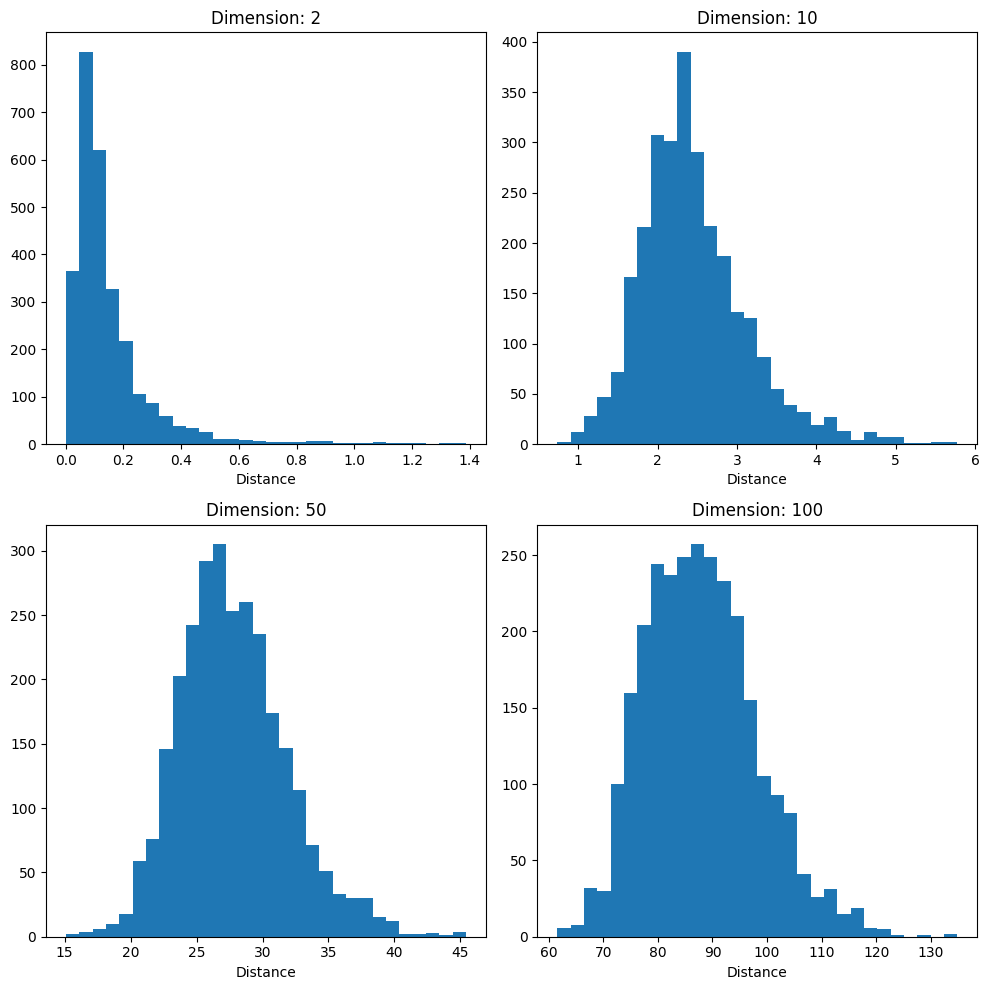

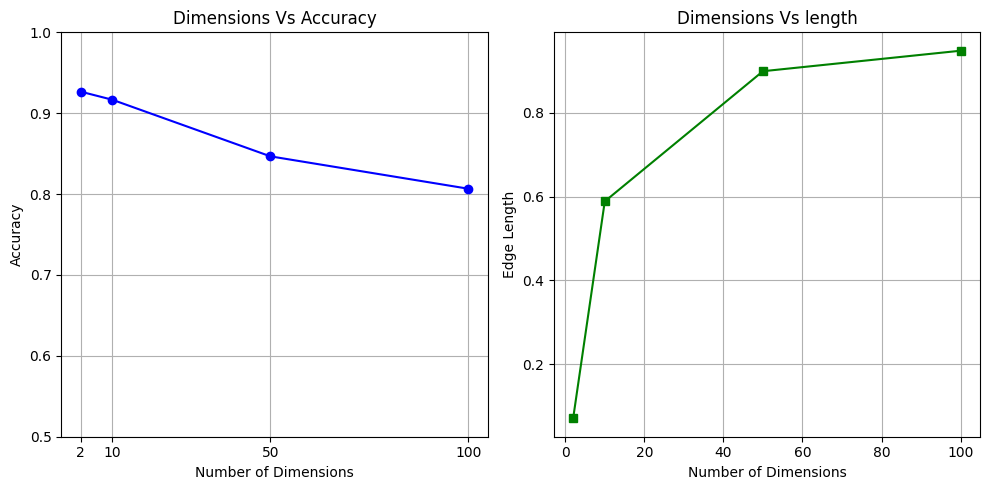

In [ ]:
# Different dimensions to test
dims = [2, 10, 50, 100]
n_samples = 1000
accuracies = []
edge_lengths = []
n_neighbors = 5

# Plot results
fig, ax = plt.subplots(nrows=2, ncols=2,figsize=(10, 10))

for i,d in enumerate(dims):
    # Create synthetic dataset
    # Ensure n_informative is at least 2
    n_informative_features = max(2, int(d*0.6))
    X, y = make_classification(n_samples=n_samples, n_features=d, n_informative=n_informative_features,
                               n_redundant=int(d*0.2), n_repeated=0, n_classes=2, random_state=42)

    # Split into train/test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)



    # Predict and evaluate accuracy
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    edge_length = (n_neighbors/n_samples)** (1/d)
    edge_lengths.append(edge_length)

    # calculate the pair distance and
    distances , indices = knn.kneighbors(X_train)
    #pairwise_distances = pairwise_distances(distances)
    ax[i // 2, i % 2].hist(distances[:,1:].flatten(),bins=30)
    ax[i // 2, i % 2].set_xlabel('Distance')
    ax[i // 2, i % 2].set_title(f'Dimension: {d}')

plt.tight_layout()


# Plot results
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(10, 5))

ax[0].plot(dims, accuracies, marker='o', linestyle='-', color='blue')
ax[0].set_title('Dimensions Vs Accuracy')
ax[0].set_xlabel('Number of Dimensions')
ax[0].set_ylabel('Accuracy')
ax[0].grid(True)
ax[0].set_xticks(dims)
ax[0].set_ylim(0.5, 1.0)

ax[1].plot(dims, edge_lengths, marker='s', color='green')
ax[1].set_title('Dimensions Vs length')
ax[1].set_xlabel('Number of Dimensions')
ax[1].set_ylabel('Edge Length')
ax[1].grid(True)

plt.tight_layout()
plt.show()

### We can conclude that in high dimensional space , data points are far from each other which violate the KNN assumption hence KNN model does not work well on high demensional space (Curse of dimentionality).